# Package

In [142]:
library(tidyverse)
library(data.table)
library(showtext)
library(ragg)
library(psych)
theme_set(theme_minimal())

##  글꼴 추가 및 셋팅
font_path <- "C:/Users/lgc/AppData/Local/Microsoft/Windows/Fonts/KoPub Dotum Light.ttf"
font_add(family = "kopub", regular = font_path)

## 이미지 저장 폰트 화질 및 크기 고정
showtext_opts(dpi = 200) 
showtext_auto()

## R 그래프 이미지 그릴 시 기본 셋팅
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200) 

# Data load

In [143]:
data <- fread('medical_insurance.csv')
glimpse(data)

Rows: 2,772
Columns: 7
$ age      <int> 19, 18, 28, 33, 32, 31, 46, 37, 37, 60, 25, 62, 23, 56, 27, 1…
$ sex      <chr> "female", "male", "male", "male", "male", "female", "female",…
$ bmi      <dbl> 27.900, 33.770, 33.000, 22.705, 28.880, 25.740, 33.440, 27.74…
$ children <int> 0, 1, 3, 0, 0, 0, 1, 3, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0…
$ smoker   <chr> "yes", "no", "no", "no", "no", "no", "no", "no", "no", "no", …
$ region   <chr> "southwest", "southeast", "southeast", "northwest", "northwes…
$ charges  <dbl> 16884.924, 1725.552, 4449.462, 21984.471, 3866.855, 3756.622,…


---

# Data processing

`1` 컬럼명 변경

In [144]:
data <- data %>% 
            rename(
                y = charges,
                x1 = age,
                x2 = sex,
                x3 = bmi,
                x4 = children,
                x5 = smoker,
                x6 = region
            )

`2` 문자형 변수 factor 처리

In [145]:
data <- data %>% 
            mutate_if(is.character, as.factor)

---

# EDA

## 반응변수(의료비) 분포 확인

`1` Y 분포

In [146]:
fig1 <- data %>% 
        ggplot(aes(x = y)) +
            geom_histogram(bins = 40, color = 'darkblue', fill = 'steelblue', alpha = 0.8) +
            labs(
                title = 'Histogram of Charge(Y) ',
                y = '빈도',
                x = '단위: 달러($)'
            ) +
        theme(
            text = element_text(family = 'kopub'),
            plot.title = element_text(size = 24, face = 'bold', hjust = 0.5),
            axis.title = element_text(size = 18),
            axis.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 14),
            axis.title.y = element_blank()
        )

ggsave(filename = "Figure/01. 반응변수 분포1.png",
        plot = fig1,
        units = "mm",
        dpi = 200,
        width = 170,
        height = 170)

`2` log(y) 분포

In [147]:
fig2 <- data %>% 
        ggplot(aes(x = log(y))) +
            geom_histogram(bins = 40, color = 'darkblue', fill = 'steelblue', alpha = 0.8) +
            labs(
                title = 'Histogram of Charge(Y) ',
                y = '빈도',
                x = '단위: 달러($)'
            ) +
        theme(
            text = element_text(family = 'kopub'),
            plot.title = element_text(size = 24, face = 'bold', hjust = 0.5),
            axis.title = element_text(size = 18),
            axis.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 14),
            axis.title.y = element_blank()
        )

ggsave(filename = "Figure/02. 반응변수 분포2.png",
        plot = fig2,
        units = "mm",
        dpi = 200,
        width = 170,
        height = 170)

In [148]:
data$logy <- log(data$y)

## 상관분석

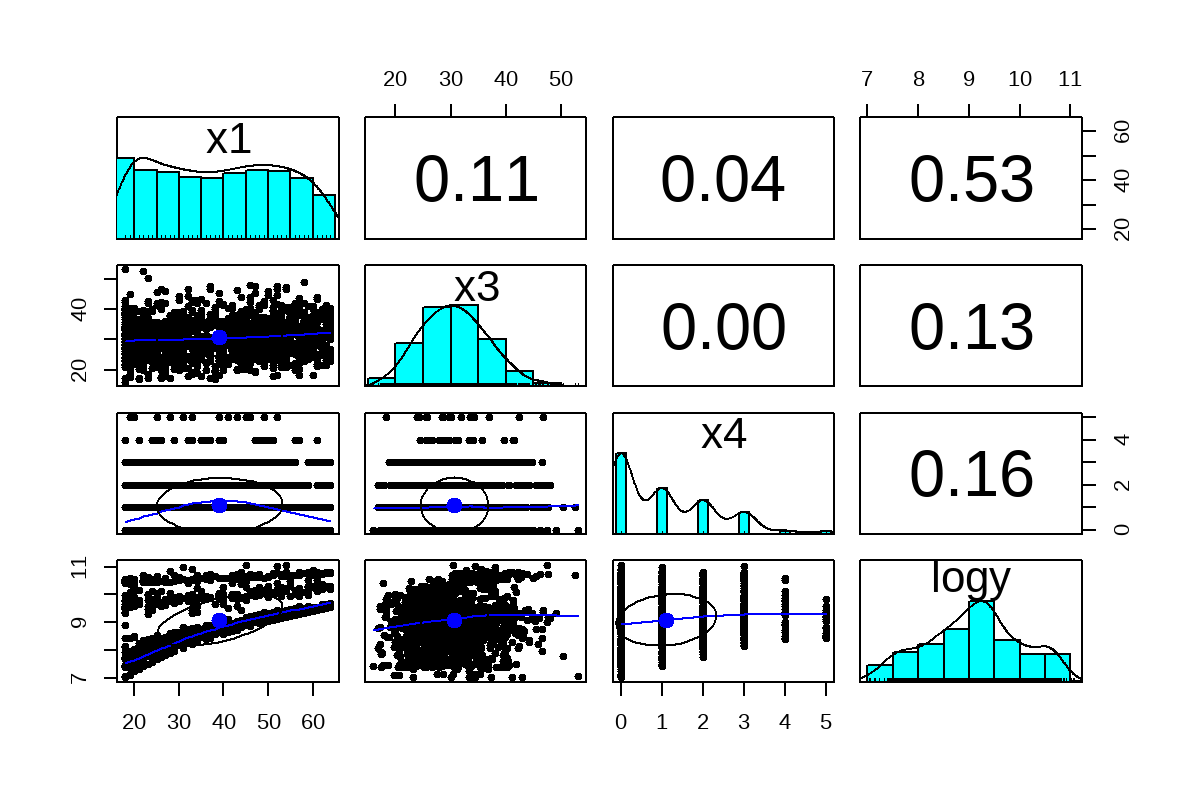

In [149]:
pairs.panels(x = data %>% 
                    select_if(is.numeric) %>% 
                        select(-y))

In [150]:
png(filename = "Figure/03. 상관분석.png", width = 800, height = 800, res = 200)
pairs.panels(x = data %>% 
                    select_if(is.numeric) %>% 
                        select(-y))

dev.off()

agg_record_1ee06bb018fa 
                      2

---

# Modeling

## 로그변환 전후 비교

`1` 기본적인 다중 선형 회귀모델 적합

In [153]:
m1 <- lm(y~., data %>% select(-logy))
m2 <- lm(logy~., data %>% select(-y))

In [152]:
summary(m1)


Call:
lm(formula = y ~ ., data = data %>% select(-logy))

Residuals:
   Min     1Q Median     3Q    Max 
-11489  -2789  -1016   1340  29867 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -11635.451    686.885 -16.939  < 2e-16 ***
x1             255.577      8.268  30.913  < 2e-16 ***
x2male         -56.944    231.866  -0.246  0.80602    
x3             330.015     19.869  16.609  < 2e-16 ***
x4             506.343     95.164   5.321 1.12e-07 ***
x5yes        23976.197    288.461  83.118  < 2e-16 ***
x6northwest   -331.841    334.380  -0.992  0.32109    
x6southeast  -1078.362    334.418  -3.225  0.00128 ** 
x6southwest  -1055.254    333.121  -3.168  0.00155 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6073 on 2763 degrees of freedom
Multiple R-squared:  0.7509,	Adjusted R-squared:  0.7502 
F-statistic:  1041 on 8 and 2763 DF,  p-value: < 2.2e-16


In [154]:
summary(m2)


Call:
lm(formula = logy ~ ., data = data %>% select(-y))

Residuals:
     Min       1Q   Median       3Q      Max 
-1.05374 -0.20306 -0.05006  0.06322  2.17807 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  7.0390040  0.0505736 139.183  < 2e-16 ***
x1           0.0346210  0.0006087  56.875  < 2e-16 ***
x2male      -0.0748546  0.0170717  -4.385 1.20e-05 ***
x3           0.0130682  0.0014629   8.933  < 2e-16 ***
x4           0.1027302  0.0070067  14.662  < 2e-16 ***
x5yes        1.5629835  0.0212387  73.591  < 2e-16 ***
x6northwest -0.0558979  0.0246196  -2.270   0.0233 *  
x6southeast -0.1687408  0.0246224  -6.853 8.87e-12 ***
x6southwest -0.1351874  0.0245269  -5.512 3.88e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4472 on 2763 degrees of freedom
Multiple R-squared:  0.7666,	Adjusted R-squared:  0.7659 
F-statistic:  1134 on 8 and 2763 DF,  p-value: < 2.2e-16
